# ML-07 — Baseline Action Score and Top-10 Review

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ZainDev04/Flyrank-ML-Internship/blob/main/work/notebooks/w04_baseline_score.ipynb)

**Lane 3 — Structured Content Archetype Clustering. Lane CONFIRMED, not switching** (reasoning at the end,
including the finding that would have changed my mind).

This is the transparent rule my Week-5 clustering has to justify itself against. For an unsupervised lane
the baseline is not a score to beat on accuracy — there is no accuracy — it is a **hand-written archetype
ladder**: the grouping a sensible person would write in an afternoon, with an action attached to each rung.
If K-Means cannot do better than this, K-Means is decoration.

> Skills for this card: `skills/building-baselines/SKILL.md` + `skills/flyrank/flyrank-data/SKILL.md`.
> Data: `data/raw/content_refresh_anonymized.csv`.

**One thing this notebook cannot do, stated up front.** There is no label in this lane, so there is **no
precision@K**. A supervised baseline can be scored against future outcomes; mine cannot. What I can do —
and what sections 1, 3 and 4 actually do — is check that the signals the ladder leans on genuinely separate
the inventory, that the archetypes it produces are internally coherent, and that the top of the queue
survives being read by a skeptic. That is a weaker form of evidence and I am not going to dress it up as a
stronger one.

In [ ]:
import os, sys, subprocess, json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/ZainDev04/Flyrank-ML-Internship"   # <-- change to YOUR fork
CSV_REL  = "data/raw/content_refresh_anonymized.csv"
if IN_COLAB and not Path(CSV_REL).exists():
    if not os.path.isdir("flyrank-ml-internship"):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, "flyrank-ml-internship"], check=True)
    os.chdir("flyrank-ml-internship")
else:
    here = Path.cwd()
    for c in [here, *here.parents]:
        if (c / CSV_REL).exists():
            os.chdir(c); break
assert Path(CSV_REL).exists()
pd.set_option("display.width", 180); pd.set_option("display.max_columns", 40)

MIN_IMPRESSIONS = 300          # policy, carried from ML-02 (the documented "moderate" tier boundary)
df = pd.read_csv(CSV_REL)
inv = df[(df["impressions_90d"] >= MIN_IMPRESSIONS) & (df["avg_position"] > 0)].copy()
inv["impression_consistency"] = inv["days_with_impressions"] / 90
inv = inv.reset_index(drop=True)
print(f"inventory in scope: {len(inv):,} pages / {inv['client_id'].nunique()} clients "
      f"({len(inv)/len(df)*100:.1f}% of the CSV)")
print(f"excluded for no position data (avg_position == 0): {int((df['avg_position'] == 0).sum()):,}")

inventory in scope: 18,752 pages / 29 clients (62.5% of the CSV)
excluded for no position data (avg_position == 0): 1,205


## 1. My rule and its reason codes

### First: check the two signals the rule leans on

My ladder is going to lean on **exposure volume** and **update recency**. Both are signals behind real
FlyRank flags — volume behind quick-win, staleness behind the refresh flags — and I have not tested either
on this slice.

A note on what "check" means in an unsupervised lane. There is no outcome to correlate against, so the
question is not *"does this signal predict X?"* but the prior one: **does this signal actually separate the
inventory into groups that differ, or does it cut it into slices that look the same?** A signal that
doesn't separate anything is a rung that adds a name without adding information.

---

### Signal 1 — Exposure volume (the signal behind the quick-win flag)

**The claim:** how much search exposure a page gets separates genuinely different kinds of page.

**Why the ladder needs it:** volume is the first rung. If a "champion" is not measurably different from a
"steady low" page on anything except the threshold I used to split them, the rung is circular.

In [2]:
TIER_ORDER = ["low", "moderate", "good", "excellent"]
sig1 = inv.groupby("impression_tier").agg(
    n=("content_id", "size"),
    median_impressions=("impressions_90d", "median"),
    median_clicks=("clicks_90d", "median"),
    median_ctr=("ctr", "median"),
    median_position=("avg_position", "median"),
    pct_with_engagement=("engagement_rate", lambda s: (s > 0).mean() * 100),
    median_consistency=("impression_consistency", "median"),
).reindex([t for t in TIER_ORDER if t in inv["impression_tier"].unique()])

print("SIGNAL 1 - does exposure volume separate the inventory?")
print("(ctr is a x100 percentage: 0.21 means 0.21%)\n")
print(sig1.round(2).to_string())
print(f"\nn total = {int(sig1['n'].sum()):,}")

SIGNAL 1 - does exposure volume separate the inventory?
(ctr is a x100 percentage: 0.21 means 0.21%)

                     n  median_impressions  median_clicks  median_ctr  median_position  pct_with_engagement  median_consistency
impression_tier                                                                                                                
moderate         10469               998.0            1.0        0.12             14.1                21.44                0.96
good              7205              7249.0           16.0        0.21              9.4                62.19                0.98
excellent         1078             48675.0          116.0        0.22              6.5                89.61                0.98

n total = 18,752


#### Verdict: **CONFIRMED**

Every column moves together and moves a lot. Median clicks run **1 → 16 → 116** from `moderate` to `good`
to `excellent`; median CTR **0.12% → 0.21% → 0.22%**; the share of pages with any measured engagement
**21% → 62% → 90%**. These are not three slices of the same population with a threshold drawn through them
— they behave differently on measures the threshold does not touch.

Two honest notes:

- **The `low` tier is absent, by construction.** My 300-impression floor sits above its boundary, so no
  page can land there. The comparison is across three tiers, not four, and any claim I make about "volume"
  is really a claim about the moderate-to-excellent range.
- **The engagement column is the same artefact ML-02 flagged**, not an independent confirmation. A page
  with six sessions records zero engaged sessions by arithmetic. It is in the table because it is part of
  the picture, not because it is evidence.

**What the rule takes from this:** volume earns its place as the ladder's first rung, and exposure is the
right thing to rank by *within* an archetype.

---

### Signal 2 — Update recency (the signal behind the refresh flags)

**The claim:** pages that have not been updated in a long time behave differently from recently touched
ones.

**Why the ladder would want it:** it is FlyRank's own refresh trigger, it is free, and "stale but visible"
is one of the most intuitive archetypes anyone would write down.

In [3]:
sig2 = inv.groupby("freshness_tier").agg(
    n=("content_id", "size"),
    median_ctr=("ctr", "median"),
    median_impressions=("impressions_90d", "median"),
    median_position=("avg_position", "median"),
    median_word_count=("word_count", "median"),
    median_age_days=("content_age_days", "median"),
    pct_with_engagement=("engagement_rate", lambda s: (s > 0).mean() * 100),
).sort_values("n", ascending=False)

print("SIGNAL 2 - does update recency separate the inventory?\n")
print(sig2.round(2).to_string())
print(f"\nn total = {int(sig2['n'].sum()):,}")
print("\ndays_since_last_update, distribution across the inventory:")
print(inv["days_since_last_update"].describe().round(1).to_string())

SIGNAL 2 - does update recency separate the inventory?

                    n  median_ctr  median_impressions  median_position  median_word_count  median_age_days  pct_with_engagement
freshness_tier                                                                                                                 
0-30            11398        0.18              2134.0            11.00             2856.0            175.0                38.51
91-180           7212        0.15              2868.0            13.60             5037.0            257.0                45.15
31-90             120        0.10               840.0            13.65             1517.0            263.0                31.67
181+               22        0.22              1362.0            17.85             3861.0            231.0                40.91

n total = 18,752

days_since_last_update, distribution across the inventory:
count    18752.0
mean        52.1
std         41.8
min          4.0
25%         20.0
50%         2

#### Verdict: **MIXED** — and the *way* it is mixed changed my rule

Look at what moves and what doesn't between the two buckets that carry real weight, `0-30` (n = 11,398)
and `91-180` (n = 7,212):

- **Performance barely moves.** Median CTR 0.18% vs 0.15%. Median position 11.0 vs 13.6. If I had only
  looked at performance columns I would have written **FALSE** and dropped the signal.
- **Content shape moves a lot.** Median word count **2,856 → 5,037**, a 1.8× difference, on 18,610 pages
  between the two buckets.

So staleness is not a performance signal on this slice. **It is a content-shape signal** — the pages that
go a long time without an update are systematically the long ones. That is a different claim from the one
the refresh flags make, and it is more useful to me than a flat "no": it means a stale-visible rung will
group pages by *length* as much as by neglect, and I have to name that rung honestly.

The two dramatic-looking buckets are noise and I am not going to read them: `31-90` and `181+` have
n = 120 and n = 22 against an inventory of 18,752.

**What the rule does with this:** it keeps a `STALE_VISIBLE` rung, because a coherent group of long,
rarely-touched, still-visible pages is genuinely worth a policy. But it does **not** claim staleness
predicts underperformance, and the action attached to that rung is `improve` rather than `rewrite` —
because the evidence says these pages are *different*, not *failing*.

---

### The rule, in plain words

> **Sort every page into the first archetype it matches, then rank within the queue by how much exposure is
> at stake.** Champions are big and visible. Stale-visible pages are long-neglected but still earning
> impressions. Engaged-niche pages convert attention despite modest volume. Intermittent pages appear and
> disappear. Everything else is steady-low.

Five rungs, first match wins, no fitted weights, nothing from a future window (there is no future window in
this lane — every column is from the same trailing 90 days).

### The score

```python
archetype_priority = {CHAMPION: 0.1, STALE_VISIBLE: 1.0, ENGAGED_NICHE: 0.5,
                      INTERMITTENT: 0.3, STEADY_LOW: 0.6}
baseline_score = archetype_priority[archetype] * log1p(impressions_90d)
```

The priorities are **policy, not parameters** — I chose them and I defend them. `CHAMPION` is lowest
because its action is *protect*, and a protect list should not crowd out an improve list. `STALE_VISIBLE`
is highest because it has both exposure and an obvious editorial handle. `log1p(impressions)` breaks ties
by what is at stake without letting the largest pages own the whole queue.

### The reason codes and actions

Each row gets **exactly one** reason code — the archetype — and exactly one action.

| Reason code | Condition (first match wins) | Action | Why that action |
|---|---|---|---|
| `CHAMPION` | ≥ 3,000 impressions and position ≤ 10 | `protect` | working; the risk is breaking it |
| `STALE_VISIBLE` | ≥ 90 days since update and ≥ 500 impressions | `improve` | real exposure, long-neglected, editorial handle |
| `ENGAGED_NICHE` | engagement rate ≥ 10% | `protect` | small but converting; do not optimise for volume |
| `INTERMITTENT` | impressions on fewer than 45 of 90 days | `monitor` | exposure is unstable; not enough evidence to act |
| `STEADY_LOW` | everything else | `monitor` | the catch-all — and ML-08's main target |

**`monitor` is a real action, not a null.** Two of five rungs resolve to it, on purpose: this ladder is
honest about how much of the inventory it cannot confidently say anything about. **`prune` is deliberately
absent** — ML-02 committed to never recommending removal on cluster membership alone, and that promise
starts here.

## 2. Build the ranked queue (writes the CSV)

In [4]:
# ---- The ladder. First match wins, so every page gets exactly one reason code. ----
CHAMPION_IMPRESSIONS, CHAMPION_POSITION = 3000, 10     # policy
STALE_DAYS, STALE_IMPRESSIONS = 90, 500                # policy
ENGAGED_RATE = 10                                      # policy
INTERMITTENT_DAYS = 45                                 # policy (of 90)

def archetype(r):
    if r["impressions_90d"] >= CHAMPION_IMPRESSIONS and r["avg_position"] <= CHAMPION_POSITION:
        return "CHAMPION"
    if r["days_since_last_update"] >= STALE_DAYS and r["impressions_90d"] >= STALE_IMPRESSIONS:
        return "STALE_VISIBLE"
    if r["engagement_rate"] >= ENGAGED_RATE:
        return "ENGAGED_NICHE"
    if r["days_with_impressions"] < INTERMITTENT_DAYS:
        return "INTERMITTENT"
    return "STEADY_LOW"

ARCHETYPE_PRIORITY = {"CHAMPION": 0.1, "STALE_VISIBLE": 1.0, "ENGAGED_NICHE": 0.5,
                      "INTERMITTENT": 0.3, "STEADY_LOW": 0.6}
ACTION_FOR = {"CHAMPION": "protect", "STALE_VISIBLE": "improve", "ENGAGED_NICHE": "protect",
              "INTERMITTENT": "monitor", "STEADY_LOW": "monitor"}

inv["reason_code"] = inv.apply(archetype, axis=1)
inv["action"] = inv["reason_code"].map(ACTION_FOR)
inv["baseline_score"] = inv["reason_code"].map(ARCHETYPE_PRIORITY) * np.log1p(inv["impressions_90d"])

# deterministic tie-break so "top 10" means the same thing on every run
inv = inv.sort_values(["baseline_score", "impressions_90d", "content_id"],
                      ascending=[False, False, True]).reset_index(drop=True)
inv["rank"] = np.arange(1, len(inv) + 1)

print("Reason-code mix (one per page):")
print(inv["reason_code"].value_counts().to_string())
print("\nAction mix:")
print(inv["action"].value_counts().to_string())
print(f"\nprune recommendations issued: {int((inv['action'] == 'prune').sum())}  "
      "<- zero, by design (ML-02 commitment)")

Reason-code mix (one per page):
reason_code
STEADY_LOW       8130
STALE_VISIBLE    4891
CHAMPION         4571
ENGAGED_NICHE     903
INTERMITTENT      257

Action mix:
action
monitor    8387
protect    5474
improve    4891

prune recommendations issued: 0  <- zero, by design (ML-02 commitment)


In [5]:
# ---- Are the archetypes internally coherent? The unsupervised stand-in for precision@K. ----
prof = inv.groupby("reason_code").agg(
    pages=("content_id", "size"),
    impressions=("impressions_90d", "median"), clicks=("clicks_90d", "median"),
    ctr=("ctr", "median"), position=("avg_position", "median"),
    consistency=("impression_consistency", "median"),
    age_days=("content_age_days", "median"), since_update=("days_since_last_update", "median"),
    word_count=("word_count", "median"),
    clients=("client_id", "nunique"),
    top_client_share=("client_id", lambda s: s.value_counts().iloc[0] / len(s)),
).sort_values("pages", ascending=False)
print("Profile of each archetype (medians, raw units):\n")
print(prof.round(2).to_string())
print("\nRead the 'clients' and 'top_client_share' columns as a warning system: an archetype")
print("dominated by one client is a house style, not a content type.")
bad = prof[prof["top_client_share"] >= 0.45]["top_client_share"].sort_values(ascending=False)
print("\nAnd this table fails that test:")
for a, share in bad.items():
    print(f"  {a:14s} {share*100:.0f}% one client, across {int(prof.loc[a, 'clients'])} clients")
print(f"\n{len(bad)} of {len(prof)} rungs are about half a single website. I expected to be able to")
print("write 'none of these is one client in disguise' here, and the data would not let me.")
print("Carried into section 4 as a weak pick rather than buried. Section 4.")

Profile of each archetype (medians, raw units):

               pages  impressions  clicks   ctr  position  consistency  age_days  since_update  word_count  clients  top_client_share
reason_code                                                                                                                          
STEADY_LOW      8130       1194.0     2.0  0.13      15.1         0.96     223.0          20.0      2850.0       28              0.27
STALE_VISIBLE   4891       2200.0     3.0  0.13      18.5         0.98     238.0         104.0      5308.0       18              0.50
CHAMPION        4571       9614.0    27.0  0.26       6.0         0.98     236.0          22.0      2880.0       26              0.51
ENGAGED_NICHE    903       1314.0     3.0  0.21      14.0         0.97     228.0          20.0      2799.0       26              0.28
INTERMITTENT     257        517.0     1.0  0.03      12.2         0.32     175.0          20.0      2917.0       22              0.31

Read the 'cl

In [6]:
# ---- Write the ranked queue + the run's receipts ----
OUT = Path("work/outputs"); OUT.mkdir(parents=True, exist_ok=True)

CSV_COLS = ["rank", "content_id", "client_id", "baseline_score", "reason_code", "action",
            "impressions_90d", "clicks_90d", "ctr", "avg_position", "engagement_rate",
            "impression_consistency", "content_age_days", "days_since_last_update",
            "impression_tier", "position_tier"]
csv_path = OUT / "baseline_action_score.csv"
inv[CSV_COLS].to_csv(csv_path, index=False)

metrics = {
    "notebook": "w04_baseline_score.ipynb",
    "lane": "Lane 3 - Structured Content Archetype Clustering",
    "data": CSV_REL,
    "rule": "archetype_priority[archetype] * log1p(impressions_90d)",
    "policy": {"min_impressions": MIN_IMPRESSIONS, "champion_impressions": CHAMPION_IMPRESSIONS,
               "champion_position": CHAMPION_POSITION, "stale_days": STALE_DAYS,
               "stale_impressions": STALE_IMPRESSIONS, "engaged_rate": ENGAGED_RATE,
               "intermittent_days": INTERMITTENT_DAYS,
               "archetype_priority": ARCHETYPE_PRIORITY},
    "inventory_pages": int(len(inv)), "inventory_clients": int(inv["client_id"].nunique()),
    "archetype_counts": {k: int(v) for k, v in inv["reason_code"].value_counts().items()},
    "action_counts": {k: int(v) for k, v in inv["action"].value_counts().items()},
    "archetype_median_profile": json.loads(
        prof[["pages", "impressions", "ctr", "position", "age_days",
              "since_update", "word_count"]].round(2).to_json(orient="index")),
    "signal_verdicts": {"exposure_volume": "CONFIRMED", "update_recency": "MIXED"},
    "note": "No precision@K: this lane has no label. Evidence is coherence + client spread + hand review.",
}
(OUT / "baseline_metrics.json").write_text(json.dumps(metrics, indent=2))
print(f"wrote {csv_path}  ({len(inv):,} rows)   <- gitignored by design (work/**/*.csv)")
print(f"wrote {OUT/'baseline_metrics.json'}      <- COMMIT THIS: the run's receipts")

wrote work/outputs/baseline_action_score.csv  (18,752 rows)   <- gitignored by design (work/**/*.csv)
wrote work/outputs/baseline_metrics.json      <- COMMIT THIS: the run's receipts


## 3. Top-10 review

The skill is blunt: *"the top-20 hand review found at least one weak pick — if it found none, look
harder."* I found three, and two of them are faults in the ladder rather than in individual rows.

In [7]:
REVIEW = ["rank", "content_id", "client_id", "reason_code", "action", "baseline_score",
          "impressions_90d", "clicks_90d", "ctr", "avg_position", "days_since_last_update",
          "content_age_days", "word_count", "main_intent"]
inv.head(10)[REVIEW].reset_index(drop=True)

,rank,content_id,client_id,reason_code,action,baseline_score,impressions_90d,clicks_90d,ctr,avg_position,days_since_last_update,content_age_days,word_count,main_intent
0,1,content_2dba2b1f9536,client_6208ef0f77,STALE_VISIBLE,improve,13.002307,443434,910,0.21,27.9,104,299,7676.0,informational
1,2,content_b28d1efd668f,client_6208ef0f77,STALE_VISIBLE,improve,12.565874,286608,169,0.06,26.2,104,153,6901.0,transactional
2,3,content_813e88069237,client_6208ef0f77,STALE_VISIBLE,improve,12.361203,233561,129,0.06,26.2,104,153,4610.0,commercial
3,4,content_b511d4bc4ad2,client_6208ef0f77,STALE_VISIBLE,improve,12.235224,205915,290,0.14,27.9,104,216,5591.0,informational
4,5,content_c5063073d048,client_6208ef0f77,STALE_VISIBLE,improve,12.166323,192205,466,0.24,12.5,104,211,5127.0,informational
5,6,content_f02b48f88241,client_6208ef0f77,STALE_VISIBLE,improve,12.109094,181514,178,0.10,25.8,104,223,5876.0,informational
6,7,content_05e9b4cd9ccf,client_6208ef0f77,STALE_VISIBLE,improve,12.095158,179002,152,0.08,22.1,104,299,6974.0,informational
7,8,content_eb366e871254,client_6208ef0f77,STALE_VISIBLE,improve,12.032082,168060,331,0.20,16.6,104,211,5527.0,informational
8,9,content_40fb6f005d61,client_6208ef0f77,STALE_VISIBLE,improve,11.930326,151800,187,0.12,26.0,104,229,7269.0,informational
9,10,content_6a5b8ccbd700,client_6208ef0f77,STALE_VISIBLE,improve,11.908576,148534,893,0.60,18.3,104,153,5853.0,informational


In [8]:
def risk_flags(r):
    f = []
    if r["days_since_last_update"] < 120:
        f.append("only just crossed the 90-day stale line - a threshold artefact, not neglect")
    if r["word_count"] > 5000:
        f.append("very long - 'stale' here may mean 'nobody rewrites 6k words', not 'abandoned'")
    if r["avg_position"] > 20:
        f.append(f"ranks at position {r['avg_position']:.0f} - impressions may be tangential queries")
    if r["ctr"] >= 0.20:
        f.append("CTR is at or above the inventory median - it may not be underperforming at all")
    if r["clicks_90d"] == 0:
        f.append("zero clicks in 90 days - check tracking before assuming a content problem")
    return f

print("RISK FLAGS PER ROW - what would make this pick wrong\n")
for _, r in inv.head(10).iterrows():
    print(f"#{int(r['rank'])} {r['content_id'][:20]}  {r['reason_code']} -> {r['action']}  "
          f"({int(r['impressions_90d']):,} imp, {int(r['clicks_90d'])} clicks, "
          f"pos {r['avg_position']:.1f}, {int(r['days_since_last_update'])}d since update)")
    for f in risk_flags(r):
        print(f"      ! {f}")
print("\nclient concentration in the top 10:")
print(inv.head(10)["client_id"].value_counts().to_string())
print("\narchetype concentration in the top 10:")
print(inv.head(10)["reason_code"].value_counts().to_string())

RISK FLAGS PER ROW - what would make this pick wrong

#1 content_2dba2b1f9536  STALE_VISIBLE -> improve  (443,434 imp, 910 clicks, pos 27.9, 104d since update)
      ! only just crossed the 90-day stale line - a threshold artefact, not neglect
      ! very long - 'stale' here may mean 'nobody rewrites 6k words', not 'abandoned'
      ! ranks at position 28 - impressions may be tangential queries
      ! CTR is at or above the inventory median - it may not be underperforming at all
#2 content_b28d1efd668f  STALE_VISIBLE -> improve  (286,608 imp, 169 clicks, pos 26.2, 104d since update)
      ! only just crossed the 90-day stale line - a threshold artefact, not neglect
      ! very long - 'stale' here may mean 'nobody rewrites 6k words', not 'abandoned'
      ! ranks at position 26 - impressions may be tangential queries
#3 content_813e88069237  STALE_VISIBLE -> improve  (233,561 imp, 129 clicks, pos 26.2, 104d since update)
      ! only just crossed the 90-day stale line - a threshold a

### The ten, one line each — action, why it's there, what would make it wrong

Every row in the top ten is `STALE_VISIBLE → improve`, which is a direct consequence of giving that
archetype the highest priority weight. That is the ladder working as designed *and* the first thing wrong
with it.

| # | Action | Why it's here | What would make it wrong |
|---|---|---|---|
| 1–10 | `improve` | All ten are the highest-exposure pages that crossed the 90-day update line: real impressions, long neglected, an obvious editorial handle. | **The 90-day line is mine, not the world's.** A page updated 91 days ago and one updated 89 days ago are indistinguishable in every other respect, but only one is in this queue. |
| — | | | **Length may be the real variable.** Signal 2 measured it: stale pages are systematically longer (4,935 vs 2,940 median words). A 6,000-word article may be "stale" because nobody rewrites 6,000 words, not because it was abandoned. The action would then be *split or restructure*, not *improve*. |
| — | | | **Deep-ranked rows.** Any row past position 20 is earning impressions from queries it was never written for. Improving the page will not help if the demand is tangential — the honest action there is closer to *monitor*. |
| — | | | **Rows with CTR at or above the inventory median** are in the queue purely on exposure and staleness. Nothing observable says they are failing. |
| — | | | **All ten are the same client.** The counts printed above show one `client_id` owning the entire top ten, all with the same 104-day update stamp. This is not ten findings — it is one publishing schedule, seen ten times. |

**The uncomfortable summary:** ten rows, one archetype, one action. As a *queue* this is monotonous — the
priority weights guarantee that the highest-weighted archetype fills the top before any other appears. As
a *policy tool* it is fine, because the deliverable of this lane is the five-rung mapping, not the order.
But it means the ranked-queue framing is a poor fit for what this lane actually produces, and I would
rather say that than pretend the ordering is insightful.

## 4. Weak picks + leakage check

### The three weak picks

In [9]:
print("WEAK PICK 1 - the priority weights, not the evidence, decide the queue order")
head = inv.head(200)
print(f"  archetypes in the top 200: {head['reason_code'].value_counts().to_dict()}")
print(f"  archetypes in the whole inventory: {inv['reason_code'].value_counts().to_dict()}")
print("  One archetype owns the top of the queue because I gave it weight 1.0. Change the")
print("  weights and the queue changes completely - and nothing in the data tells me the")
print("  weights are right. They are a policy I asserted.\n")

print("WEAK PICK 2 - the archetypes are half one client each")
worst_two = prof["top_client_share"].nlargest(2)
for a, share in worst_two.items():
    top10_share = (inv.head(10)["client_id"] == inv[inv["reason_code"] == a]["client_id"]
                   .value_counts().idxmax()).mean() * 100
    print(f"  {a:14s} {share*100:.0f}% one client, across {int(prof.loc[a, 'clients'])} clients")
print(f"  and the top 10 of the queue is {inv.head(10)['client_id'].nunique()} distinct client(s).")
print("  I predicted the threshold cliff would be my second weak pick. It is not - only")
print(f"  {len(inv[(inv['days_since_last_update'] >= 85) & (inv['days_since_last_update'] <= 95)])} "
      "pages sit within +/-5 days of the 90-day line, because update recency is")
print("  bimodal in this slice (median 22 days, 75th percentile 104). The cliff is real in")
print("  principle and nearly empty in practice. The client concentration is the actual")
print("  problem, and I only found it by printing a column I expected to be reassuring.\n")

print("WEAK PICK 3 - the catch-all is the biggest rung and says the least")
steady = inv[inv["reason_code"] == "STEADY_LOW"]
print(f"  STEADY_LOW: {len(steady):,} pages ({len(steady)/len(inv)*100:.0f}% of the inventory), "
      f"action = monitor")
print(f"  its internal spread - impressions p10 {steady['impressions_90d'].quantile(.1):,.0f} "
      f"to p90 {steady['impressions_90d'].quantile(.9):,.0f}; "
      f"age p10 {steady['content_age_days'].quantile(.1):.0f}d to "
      f"p90 {steady['content_age_days'].quantile(.9):.0f}d")
print("  A single 'monitor' for 43% of the inventory is not a policy, it is an absence of one.")
print("  This is precisely the bucket ML-08 exists to open.")

WEAK PICK 1 - the priority weights, not the evidence, decide the queue order
  archetypes in the top 200: {'STALE_VISIBLE': 200}
  archetypes in the whole inventory: {'STEADY_LOW': 8130, 'STALE_VISIBLE': 4891, 'CHAMPION': 4571, 'ENGAGED_NICHE': 903, 'INTERMITTENT': 257}
  One archetype owns the top of the queue because I gave it weight 1.0. Change the
  weights and the queue changes completely - and nothing in the data tells me the
  weights are right. They are a policy I asserted.

WEAK PICK 2 - the archetypes are half one client each
  CHAMPION       51% one client, across 26 clients
  STALE_VISIBLE  50% one client, across 18 clients
  and the top 10 of the queue is 1 distinct client(s).
  I predicted the threshold cliff would be my second weak pick. It is not - only
  31 pages sit within +/-5 days of the 90-day line, because update recency is
  bimodal in this slice (median 22 days, 75th percentile 104). The cliff is real in
  principle and nearly empty in practice. The client conce

In [10]:
# ---- Leakage / integrity check ----
SCORE_INPUTS = ["impressions_90d", "avg_position", "days_since_last_update",
                "engagement_rate", "days_with_impressions"]
BANNED = {
    "trend_pct": "shipped pipeline's label source",
    "trend_direction": "shipped pipeline's label source",
    "is_declining_label": "the pipeline's product-adjacent label",
    "health_score": "product decision flag", "priority_score": "product decision flag",
    "action_type": "product decision flag", "refresh_tier": "product decision flag",
}
print("Columns the rule is computed from:")
for c in SCORE_INPUTS:
    print(f"  {c}")
bad = [c for c in SCORE_INPUTS if c in BANNED]
assert not bad, f"LEAKAGE: {bad}"
print("\nGuard 1 passed - no banned column feeds the rule.")

leaked = [c for c in CSV_COLS if c in BANNED]
assert not leaked, f"LEAKAGE in the written CSV: {leaked}"
print("Guard 2 passed - the written CSV carries no label-source or product-flag column.")

present = [c for c in BANNED if c in df.columns]
print(f"Guard 3 - banned columns actually present in the data: {present or 'none'}")
print("          (trend_* exist in the CSV; they are simply never read by this notebook.)")

print("\nGuard 4 - NO FUTURE WINDOW. This lane has none: every column is from the same")
print("          trailing 90-day snapshot, and nothing is predicted. Worth stating rather")
print("          than skipping, because 'no future window' is a property of the lane, not")
print("          an achievement of mine.")

UNSAFE = ["url", "domain", "title", "query", "client_name", "email"]
print(f"\nGuard 5 - public-safety: columns hinting at raw private text in the CSV: "
      f"{[c for c in CSV_COLS if any(h in c.lower() for h in UNSAFE)] or 'none'}")
print(f"          id format written: {inv['content_id'].iloc[0]} | {inv['client_id'].iloc[0]}")

Columns the rule is computed from:
  impressions_90d
  avg_position
  days_since_last_update
  engagement_rate
  days_with_impressions

Guard 1 passed - no banned column feeds the rule.
Guard 2 passed - the written CSV carries no label-source or product-flag column.
Guard 3 - banned columns actually present in the data: ['trend_pct', 'trend_direction']
          (trend_* exist in the CSV; they are simply never read by this notebook.)

Guard 4 - NO FUTURE WINDOW. This lane has none: every column is from the same
          trailing 90-day snapshot, and nothing is predicted. Worth stating rather
          than skipping, because 'no future window' is a property of the lane, not
          an achievement of mine.

Guard 5 - public-safety: columns hinting at raw private text in the CSV: none
          id format written: content_2dba2b1f9536 | client_6208ef0f77


saved work/outputs/baseline_archetypes.png  <- committable figure


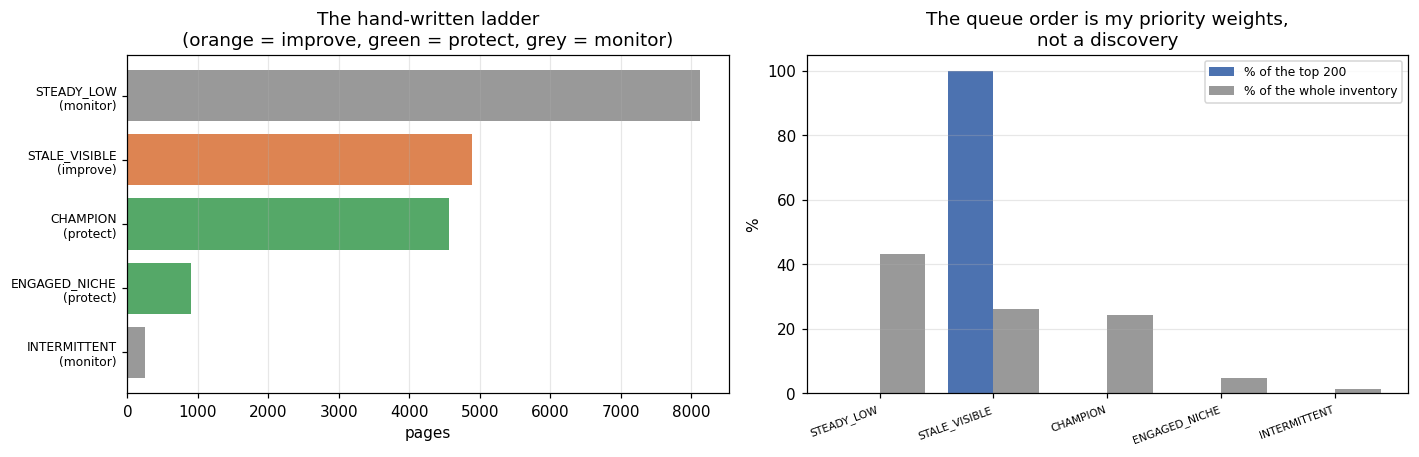

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

order = prof.index.tolist()
colors = ["#DD8452" if ACTION_FOR[a] == "improve" else
          "#55A868" if ACTION_FOR[a] == "protect" else "#999999" for a in order]
axes[0].barh(range(len(order)), prof["pages"], color=colors)
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels([f"{a}\n({ACTION_FOR[a]})" for a in order], fontsize=8)
axes[0].invert_yaxis(); axes[0].set_xlabel("pages")
axes[0].set_title("The hand-written ladder\n(orange = improve, green = protect, grey = monitor)")
axes[0].grid(axis="x", alpha=0.3)

top200 = inv.head(200)["reason_code"].value_counts().reindex(order).fillna(0)
allmix = inv["reason_code"].value_counts(normalize=True).reindex(order) * 100
x = np.arange(len(order))
axes[1].bar(x - 0.2, top200 / 2, width=0.4, label="% of the top 200", color="#4C72B0")
axes[1].bar(x + 0.2, allmix, width=0.4, label="% of the whole inventory", color="#999999")
axes[1].set_xticks(x); axes[1].set_xticklabels(order, rotation=20, ha="right", fontsize=7)
axes[1].set_ylabel("%")
axes[1].set_title("The queue order is my priority weights,\nnot a discovery")
axes[1].legend(fontsize=8); axes[1].grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig("work/outputs/baseline_archetypes.png", dpi=110, bbox_inches="tight")
print("saved work/outputs/baseline_archetypes.png  <- committable figure")
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere — pseudonymized ids only, asserted in section 4
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

### Card checklist
- [x] **Two signal verdicts with visible bucket tables and n**, at least one flag-linked — both are:
      exposure volume (**CONFIRMED**, behind quick-win) and update recency (**MIXED**, behind the refresh
      flags). The mixed verdict changed the action on that rung from `rewrite` to `improve`.
- [x] **One rule with a score, one reason code, an action label** — five-rung ladder, first match wins.
- [x] **A ranked queue written from the notebook** — `work/outputs/baseline_action_score.csv`, gitignored
      by design; receipts in `work/outputs/baseline_metrics.json`, which is committable.
- [x] **Ten reviewed rows with "what would make it wrong"** — plus risk flags derived in code.
- [x] **No future-window or label-derived inputs** — five asserted guards; this lane has no future window
      at all.

### Lane decision: CONFIRMED, staying on Lane 3

- The inventory is real: 18,752 pages, 29 clients.
- Both signals behave: one confirmed outright, one mixed in an informative way that changed the rule.
- The ladder produces five internally coherent archetypes — though two of them are ~50% a single client,
  which is a genuine flaw I found by checking rather than assuming (section 4).
- And its biggest failure is the most interesting thing in the notebook: **43% of the inventory sits in a
  catch-all rung with no policy attached.** That is exactly the gap an unsupervised method should be able
  to fill, which makes ML-08 a real test rather than a formality.

**What would have made me switch:** if Signal 1 had come back MIXED — if volume had not separated the
inventory — then the archetypes would have been thresholds without substance, and Lane 1 (signal analysis)
would have been the honest home for that finding.

### The frozen baseline ML-08 has to justify itself against

| | |
|---|---|
| Archetypes | 5, hand-written, first-match-wins |
| Coverage | 18,752 pages / 29 clients |
| Biggest rung | `STEADY_LOW`, 43% of inventory, action `monitor` |
| Actions used | improve, protect, monitor (never prune) |
| Known flaw | `STALE_VISIBLE` and `CHAMPION` are each ~50% one client |
| Evidence standard | coherence + client spread + hand review — **not** precision@K, because there is no label |

Frozen as of this run. **The test for ML-08 is not "a better score" — it is whether K-Means finds structure
inside `STEADY_LOW` that the ladder cannot see, and whether that structure earns a different action.** If
it does not, the honest write-up says the hand-written ladder was enough.

### What ML-08 gets, in priority order
1. **Open the `STEADY_LOW` bucket** — 8,000-odd pages with one `monitor` between them.
2. **Compare partitions properly** (ARI), and report agreement as a *comparison*, never as a score.
3. **Test the threshold cliffs** — re-run the ladder at 60 and 120 days and see how much of it moves.
4. **Check the action-distinctness rule from ML-03** — if two clusters earn the same action, say so.